In [1]:
import yaml
import numpy as np

def normalize_config(obj):
    """Recursively normalize:
    - numeric strings (incl. scientific notation) -> float
    - 'np.pi', 'np.e', 'np.inf' -> numpy constants
    """
    if isinstance(obj, dict):
        return {k: normalize_config(v) for k, v in obj.items()}

    if isinstance(obj, list):
        return [normalize_config(v) for v in obj]

    if isinstance(obj, str):
        s = obj.strip()

        # numpy constants
        if s == "np.pi":
            return np.pi
        if s == "np.e":
            return np.e
        if s in ("np.inf", "inf"):
            return np.inf
        if s in ("-np.inf", "-inf"):
            return -np.inf

        # numeric strings (supports "15.0e9", "200.0e6", "3.5E9", etc.)
        try:
            return float(s)
        except ValueError:
            return obj  # keep as string if not numeric

    return obj  # int/float/bool/None stay as-is


with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

cfg = normalize_config(cfg)




In [2]:
# =====================
# TensorFlow / GPU
# =====================
import os
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("GPU available:", gpus)
else:
    print("No GPU, using CPU")

if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 0  # 使用 CPU 可设为 ""
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"


# =====================
# Scientific stack
# =====================
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R

%matplotlib inline


# =====================
# Mitsuba / DrJit
# =====================
import mitsuba as mi
import drjit as dr


# =====================
# Sionna RT
# =====================
from sionna.rt import (
    load_scene,
    PlanarArray,
    Transmitter,
    Receiver,
    Camera,
    PathSolver,
    ITURadioMaterial,
    SceneObject,
    AntennaPattern,
    register_antenna_pattern,
)


# =====================
# Custom utils / scenes
# =====================
import sionnautils
from sionnautils.custom_scene import list_scenes, get_scene


# =====================
# Project-specific
# =====================
from Engine_V3 import Engine


# =====================
# Misc
# =====================
import json
from pathlib import Path
import yaml


2026-01-23 01:27:52.211088: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-23 01:27:52.259311: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-23 01:27:53.474103: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [ ]:
scenes = list_scenes()
print(scenes)
# engine = Engine(cfg, scenes[0])

scene_file = scenes[0]

# ------------------------------------------------------------------
# create scene
scene_path, map_data = get_scene(scene_file)
for k, v in map_data.items():
    print(f'{k}: {v}')
            
scene = load_scene(scene_path,merge_shapes=True)
        
floor = scene.get('ground')
# print(f'Floor material: {floor.radio_material.name}')
floor.radio_material = ITURadioMaterial("itu_concrete",
                                        "concrete",
                                        thickness=0.01,
                                        color=(0.5, 0.5, 0.5))

scene.remove("itu_wet_ground")

for name, obj in scene.objects.items():
        print(f'{name:<15}{obj.radio_material.name}')

['nyu_tandon']
bbox_lat: [40.69012764197041, 40.699120858029595]
bbox_long: [-73.99156687083165, -73.97970552916836]
address: 5 MetroTech Center, Brooklyn, NY 11201
descr: NYU Tandon campus
2026-01-23 01:27:59 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
no-name-1      itu_marble
ground         itu_concrete


In [4]:
np.array(cfg["ue"]["initial_orientation"])[:,0]

array([0., 0.])

In [4]:
from collections import defaultdict

rx_fc = cfg["ue"]["rx_fc"]   # [1.5e10, 1.5e10, 3.5e9, 3.5e9]

fc_to_rx_idx = defaultdict(list)
for rx_idx, fc in enumerate(rx_fc):
    fc_to_rx_idx[fc].append(rx_idx)

n_unique_fc = len(fc_to_rx_idx)

engine = Engine(cfg, scene)

print("Number of unique fc:", n_unique_fc)
print("fc -> rx indices:", dict(fc_to_rx_idx))

Number of unique fc: 2
fc -> rx indices: {15000000000.0: [0, 1], 3500000000.0: [2, 3]}


In [5]:
hp_list, sinr_db_list, sinr_lin_list, capacity_list = engine.run_from_file(cfg["route"]["file"])
# hp_list

  0%|          | 0/1200 [00:00<?, ?it/s]

  0%|          | 4/1200 [00:00<03:41,  5.41it/s]/workspace/ruibin/fc_project/UE_fc_hopping_v2/RT_v3/Engine_V3.py:198: RuntimeWarning: divide by zero encountered in log10
  return 10.0 * np.log10(linear_values)
100%|██████████| 1200/1200 [01:55<00:00, 10.38it/s]


In [6]:
import numpy as np
import matplotlib.pyplot as plt

sinr_db = np.array(sinr_db_list)   # (N, U, R, 1, T, 1, 1) 期望这样
print("sinr_db.shape:", sinr_db.shape)

sinr_db = np.squeeze(sinr_db, axis=(3,5,6))  # -> (N, U, R, T)
print("squeezed:", sinr_db.shape)



sinr_db.shape: (1200, 1, 4, 1, 1, 1, 1)
squeezed: (1200, 1, 4, 1)


In [8]:
# dt = cfg["channel"]["measure_time"]
# t_axis = np.arange(sinr_db.shape[0]) * dt

# tx_id = 0

# U = sinr_db.shape[1]
# R = sinr_db.shape[2]

# for u in range(U):
    
#     plt.figure(figsize=(15, 2.6))
#     for r in range(R):
#         y = sinr_db[:, u, r, tx_id]
#         y = np.where(y <= -1000, np.nan, y)  # 把 -3000 这种无效值隐藏掉
#         plt.plot(t_axis, y, label=f"UE {u}, RX{r}, fc = {rx_fc[r]/1e9} GHz, BW = {cfg['ue']['rx_bw'][r]/1e6} MHz")
#     plt.ylim(-70, 70)
#     plt.xlabel("Time (s)")
#     plt.ylabel(f"SINR (dB), serving TX={tx_id}")
#     plt.title(f"UE {u}: SINR vs Time")
#     plt.legend(loc="lower left", ncol=2)
#     plt.grid(True)
#     plt.show()


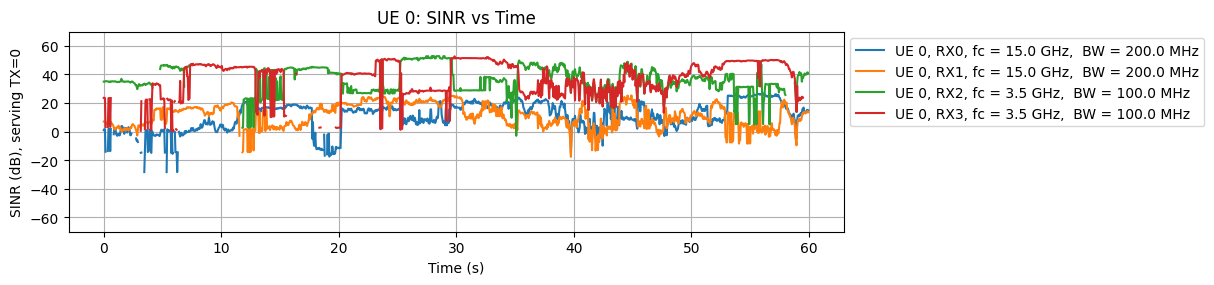

In [7]:
dt = cfg["channel"]["measure_time"]
t_axis = np.arange(sinr_db.shape[0]) * dt

# tx_id = 1

U = sinr_db.shape[1]
R = sinr_db.shape[2]

# plt.figure(figsize=(15, 2.6))

for tx_id in range(cfg["tx"]["n_tx"]):
    

    for u in range(U):
        plt.figure(figsize=(10, 2.6))
        for r in range(R):
            y = sinr_db[:, u, r, tx_id]
            y = np.where(y <= -1000, np.nan, y)  # 把 -3000 这种无效值隐藏掉
            plt.plot(t_axis, y, label=f"UE {u}, RX{r}, fc = {rx_fc[r]/1e9} GHz,  BW = {cfg['ue']['rx_bw'][r]/1e6} MHz")
        plt.ylim(-70, 70)
        plt.xlabel("Time (s)")
        plt.ylabel(f"SINR (dB), serving TX={tx_id}")
        plt.title(f"UE {u}: SINR vs Time")
        # plt.legend(loc="upper left", ncol=2)
        plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
        
        plt.grid(True)
        plt.show()


capacity.shape: (1200, 1, 4, 1, 1, 1, 1)
squeezed: (1200, 1, 4, 1)


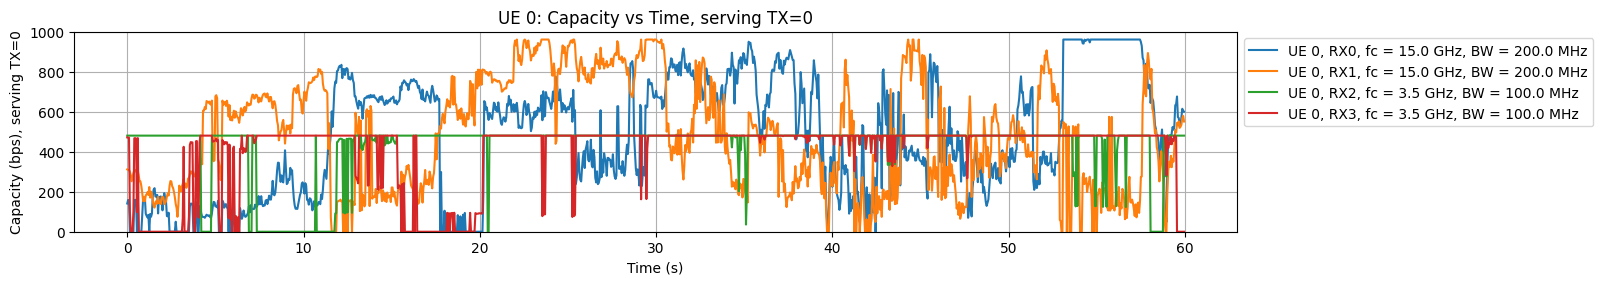

In [8]:
capacity = np.array(capacity_list)   # (N, U, R, 1, T, 1, 1) 期望这样
print("capacity.shape:", capacity.shape)

capacity = np.squeeze(capacity, axis=(3,5,6))  # -> (N, U, R, T)
print("squeezed:", capacity.shape)


dt = cfg["channel"]["measure_time"]
t_axis = np.arange(capacity.shape[0]) * dt

# tx_id = 1

U = capacity.shape[1]
R = capacity.shape[2]


for tx_id in range(cfg["tx"]["n_tx"]):
    

    for u in range(U):
        plt.figure(figsize=(15, 2.6))
        for r in range(R):
            y = capacity[:, u, r, tx_id]
            y = np.where(y <= -1000, np.nan, y)  # 把 -3000 这种无效值隐藏掉
            plt.plot(t_axis, y, label=f"UE {u}, RX{r}, fc = {rx_fc[r]/1e9} GHz, BW = {cfg['ue']['rx_bw'][r]/1e6} MHz")
        plt.ylim(0, 1000)
        plt.xlabel("Time (s)")
        plt.ylabel(f"Capacity (bps), serving TX={tx_id}")
        plt.title(f"UE {u}: Capacity vs Time, serving TX={tx_id}")
        plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
        plt.grid(True)
        plt.show()